<a href="https://colab.research.google.com/github/tejaswi1308/Fake-News-Detection-ML/blob/main/Fake_news_detection_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🟦 Sample Dataset Rows:

   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  

✅ Model Accuracy: 93.53 %

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       628
           1       0.93      0.94    

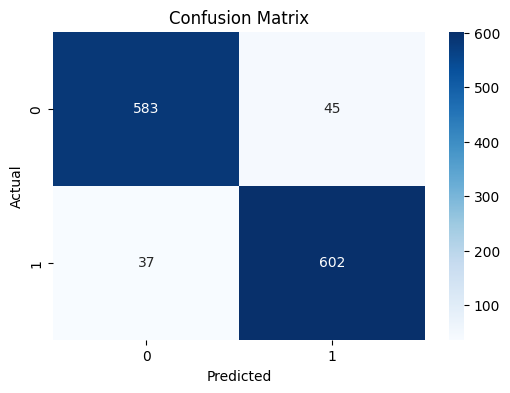


📰 News: It's primary day in New York and front-runners Hillary Clinton and Donald Trump are leading in the polls.
🔴 Prediction: Fake


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("news.csv").fillna("")


print("\n🟦 Sample Dataset Rows:\n")
print(data.head())


data["content"] = data["title"] + " " + data["text"]

data["label"] = data["label"].map({
    "FAKE":0, "fake":0, "Fake":0, "False":0,
    "REAL":1, "real":1, "True":1
}).fillna(0)

X = data["content"]
y = data["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.75,
    min_df=2,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


model = PassiveAggressiveClassifier(
    max_iter=1200,
    loss='hinge',
    C=1.0,
    random_state=42
)

model.fit(X_train_tfidf, y_train)


y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print("\n✅ Model Accuracy:", round(acc * 100, 2), "%")

print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


def predict_news(news):
    vec = vectorizer.transform([news])
    pred = model.predict(vec)[0]
    print("\n📰 News:", news)
    print("🟢 Prediction: Real" if pred == 1 else "🔴 Prediction: Fake")


test_news = "It's primary day in New York and front-runners Hillary Clinton and Donald Trump are leading in the polls."
predict_news(test_news)